<a href="https://colab.research.google.com/github/mahmlk/mahmlk/blob/main/Copy_of_Untitled10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
from PIL import Image, ImageFilter, ImageOps
from scipy.ndimage import gaussian_filter

drive.mount('/content/gdrive')

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3aietf%3awg%3aoauth%3a2.0%3aoob&scope=email%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdocs.test%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive.photos.readonly%20https%3a%2f%2fwww.googleapis.com%2fauth%2fpeopleapi.readonly%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive.activity.readonly%20https%3a%2f%2fwww.googleapis.com%2fauth%2fexperimentsandconfigs%20https%3a%2f%2fwww.googleapis.com%2fauth%2fphotos.native&response_type=code

Enter your authorization code:
4/1AX4XfWje3naiXKeqN9_HpczWrN8v5WxPd873UcGgqpSdvClL3XLAsnWCq8s
Mounted at /content/gdrive


In [ ]:
def show_image(im):
  plt.imshow(im, cmap='gray')
  plt.axis('off')
  plt.show()

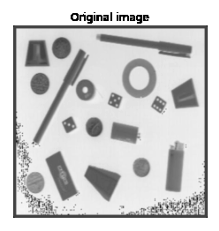

In [ ]:
im_path = 'gdrive/MyDrive/sample_image.png'
im = Image.open(im_path)
im = np.array(im)[:,:,0]
show_image(im)

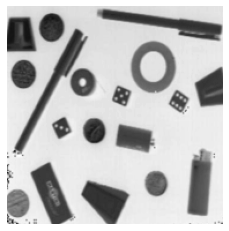

In [ ]:
w, h = im.shape
w_crop_size = int(w * 0.12)
h_crop_size = int(h * 0.1)
# Getting rid of the text at the top and the four strips
center_cropped_im = im[w_crop_size: w - w_crop_size, h_crop_size: h - h_crop_size]
show_image(center_cropped_im)

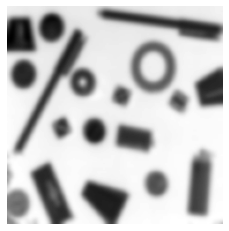

In [ ]:
# getting rid of the noise
blurred_im = gaussian_filter(center_cropped_im, sigma=2)
show_image(blurred_im)

In [ ]:
blurred_im[0][0]

226

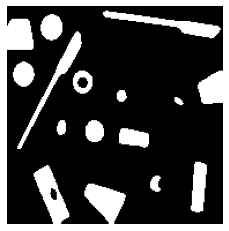

In [ ]:
initial_mask = blurred_im < 128
show_image(initial_mask)

In [ ]:
dx = [-1, 0, 0, 1]
dy = [0, -1, 1, 0]

def fill(x, y, object_matrix, initial_mask, object_id):
  object_matrix[x][y] = object_id
  for k in range(4):
    nx = x + dx[k]
    ny = y + dy[k]

    # check if the neighbor is valid
    if nx < 0 or ny < 0 or nx >= object_matrix.shape[0] or ny >= object_matrix.shape[1] or initial_mask[nx][ny] == False:
      continue

    # check if the neighbor is not previously visited
    if object_matrix[nx][ny] != 0:
      continue

    fill(nx, ny, object_matrix, initial_mask, object_id)

In [ ]:
object_matrix = np.zeros(initial_mask.shape)
object_count = 0

for i in range(object_matrix.shape[0]):
  for j in range(object_matrix.shape[1]):
    if initial_mask[i][j] == True and object_matrix[i][j] == 0:
      object_count += 1
      fill(i, j, object_matrix, initial_mask, object_count)

print('Number of objects detected in the image:', object_count)

Number of objects detected in the image: 16


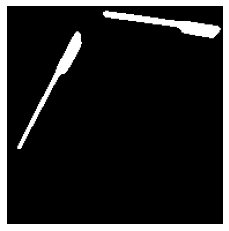

In [ ]:
pen_mask = (object_matrix == 1) + (object_matrix == 4)
show_image(pen_mask)

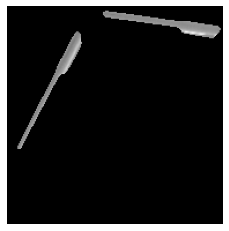

In [ ]:
show_image(np.multiply(pen_mask, center_cropped_im))